# Scale Sweep Plotting
The goal of this file is to create visualizations for the scale sweep experiments to show the exploration behaviour at different scale magnitudes

## Setup
Specify folders, load data, add tags

In [1]:
# Dictionary of folder paths and relevant tags
superfolder_paths = [
    "experiments/20260320_ab_scalesweep_novar/model_name_gemini-3.1-flash-lite-preview",
    "experiments/20260320_ab_scalesweep_novar/model_name_Olmo-3.1-32B-Instruct",
    "experiments/20260320_ab_scalesweep_novar/model_name_Qwen3-32B",
    "experiments/20260320_farm_scalesweep_novar/model_name_gemini-3.1-flash-lite-preview",
    "experiments/20260320_farm_scalesweep_novar/model_name_Olmo-3.1-32B-Instruct",
    "experiments/20260320_farm_scalesweep_novar/model_name_Qwen3-32B",
    "experiments/20260320_clothing_scalesweep_novar/model_name_gemini-3.1-flash-lite-preview",
    "experiments/20260320_clothing_scalesweep_novar/model_name_Olmo-3.1-32B-Instruct",
    "experiments/20260320_clothing_scalesweep_novar/model_name_Qwen3-32B",
]

In [2]:
import os
os.chdir("../..")

### Function: map_sf_path_to_keys

This function takes a list of folder paths and maps each path to a dictionary containing the following keys:

- **domain**: Identifies the domain based on the folder path. If the path contains "farm", it is categorized as "Farm". If it contains "abandit" or "ab", it is categorized as "Bandit". Otherwise, it is labeled as "Unknown".
- **model**: Extracts the model name from the folder path. The model name is expected to follow the pattern `model_name_[model]`.
- **variance**: Determines the variance level based on the folder path. If the path contains "4sd_var", it is categorized as "High". If it contains "2sd_var", it is categorized as "Low". Otherwise, it is labeled as "No".
- **superfolder_path**: The original folder path is included for reference.

The function returns a pandas DataFrame with columns corresponding to these keys.

In [3]:
import re
import pandas as pd

def map_sf_paths_to_keys(folder_paths):
    data = []

    for folder_path in folder_paths:
        # Determine domain
        if "farm" in folder_path:
            domain = "Farm"
        elif "abandit" in folder_path or "ab" in folder_path:
            domain = "Bandit"
        elif "clothing" in folder_path or "rec" in folder_path:
            domain = "Clothing"
        else:
            domain = "Unknown"

        # Extract model
        model_match = re.search(r"model_name_(.+?)(?:_prompt_|$)", folder_path)
        model = model_match.group(1) if model_match else "Unknown"

        # Determine variance
        if "4sd_var" in folder_path:
            variance = "High"
        elif "2sd_var" in folder_path:
            variance = "Low"
        else:
            variance = "No"

        data.append({
            "domain": domain,
            "model": model,
            "variance": variance,
            "superfolder_path": folder_path
        })

    return pd.DataFrame(data)

## Data Loading

In [4]:
superdfs_tags_df = map_sf_paths_to_keys(superfolder_paths)

In [5]:
superdfs_tags_df

,domain,model,variance,superfolder_path
0,Bandit,gemini-3.1-flash-lite-preview,No,experiments/20260320_ab_scalesweep_novar/model...
1,Bandit,Olmo-3.1-32B-Instruct,No,experiments/20260320_ab_scalesweep_novar/model...
2,Bandit,Qwen3-32B,No,experiments/20260320_ab_scalesweep_novar/model...
3,Farm,gemini-3.1-flash-lite-preview,No,experiments/20260320_farm_scalesweep_novar/mod...
4,Farm,Olmo-3.1-32B-Instruct,No,experiments/20260320_farm_scalesweep_novar/mod...
5,Farm,Qwen3-32B,No,experiments/20260320_farm_scalesweep_novar/mod...
6,Clothing,gemini-3.1-flash-lite-preview,No,experiments/20260320_clothing_scalesweep_novar...
7,Clothing,Olmo-3.1-32B-Instruct,No,experiments/20260320_clothing_scalesweep_novar...
8,Clothing,Qwen3-32B,No,experiments/20260320_clothing_scalesweep_novar...


In [6]:
# Now we shift to creating a new Dataframe for all the semantic variation folders, including the scale and nomenclature tags

# Look for subdirectories within each superfolder.
# Extract scale values from subdirectory names matching the pattern `_scale[scale_value]`.
import os
import re

# Sorted longest-first to avoid partial matches (e.g. "sent_helpful" before "helpful")
NOMENCLATURES = sorted(
    ["alphanumeric", "sem_rel_helpful", "sem_rel_mislead", "sent_new_helpful", "sent_new_mislead",
     "sent_helpful", "sent_mislead", "ordinal_helpful", "ordinal_mislead", "world_helpful", "world_mislead"],
    key=len, reverse=True
)

semantic_variation_data = []

for _, row in superdfs_tags_df.iterrows():
    superfolder_path = row['superfolder_path']

    if os.path.exists(superfolder_path):
        subdirs = [d for d in os.listdir(superfolder_path) if os.path.isdir(os.path.join(superfolder_path, d))]

        for subdir in subdirs:
            # Extract scale value — supports negative values like _scale-0.5
            scale_match = re.search(r"_scale(-?[0-9\.]+)", subdir)
            if scale_match:
                scale_value = float(scale_match.group(1))

                # Extract nomenclature via longest-first substring matching
                nomenclature = "unknown"
                for nom in NOMENCLATURES:
                    if nom in subdir:
                        nomenclature = nom
                        break

                semantic_variation_data.append({
                    **row.to_dict(),
                    "scale": scale_value,
                    "nomenclature": nomenclature,
                    "semantic_folder": os.path.join(superfolder_path, subdir)
                })

# Create a new DataFrame for semantic variation folders
semantic_variation_df = pd.DataFrame(semantic_variation_data)

In [7]:
# Iterate through each semantic variation folder and find shuffle subfolders
import os
from glob import glob

replicate_data = []

for _, row in semantic_variation_df.iterrows():
    semantic_folder = row['semantic_folder']
    shuffle_folder = f"{semantic_folder}/shuffles"

    if os.path.exists(shuffle_folder):
        # Find all shuffle subfolders
        shuffle_paths = glob(f"{shuffle_folder}/shuffle_*")

        for shuffle_path in shuffle_paths:
            # Find all jsonl files in the shuffle folder
            jsonl_files = glob(f"{shuffle_path}/*.jsonl")

            # Sort files by modification time (most recent first)
            jsonl_files.sort(key=os.path.getmtime, reverse=True)

            for jsonl_file in jsonl_files:
                try:
                    # Read the jsonl file
                    df = pd.read_json(jsonl_file, lines=True)

                    # Record the number of rows in the file
                    row_count = len(df)
                    replicate_data.append({
                        **row.to_dict(),
                        "shuffle_number": os.path.basename(shuffle_path).split("_")[-1],
                        "jsonl_file": jsonl_file,
                        "row_count": row_count
                    })
                    break  # Only take the most recent valid file
                except Exception as e:
                    continue

# Create a new DataFrame for replicates
replicate_df = pd.DataFrame(replicate_data)
# replicate_df

## Visualization
Generate two kinds of plot. First, plot the mean steps to exploration for each scale value. Then, plot the distributions for each scale individually.

### Report distributional statistics
For each model, domain, and 

In [8]:
# Summary table: each row is a (model, domain, nomenclature, scale) combination
# Grouped by model > domain > nomenclature, scale sorted ascending
summary_df = (
    replicate_df
    .groupby(['model', 'domain', 'nomenclature', 'scale'], sort=False)
    .agg(
        n_replicates=('row_count', 'count'),
        median_turns=('row_count', 'median'),
        mean_turns=('row_count', 'mean'),
        prop_at_least_3=('row_count', lambda x: (x >= 3).mean()),
        prop_at_least_10=('row_count', lambda x: (x >= 10).mean()),
    )
    .reset_index()
    .sort_values(['model', 'domain', 'nomenclature', 'scale'], ascending=[True, True, True, True])
    .reset_index(drop=True)
)

summary_df['median_turns'] = summary_df['median_turns'].round(2)
summary_df['mean_turns'] = summary_df['mean_turns'].round(2)
summary_df['prop_at_least_3'] = summary_df['prop_at_least_3'].round(2)
summary_df['prop_at_least_10'] = summary_df['prop_at_least_10'].round(2)

print(summary_df.to_string(index=False))
print("\n--- LaTeX ---\n")
print(summary_df.to_latex(index=False, float_format="%.2f"))

                        model   domain    nomenclature  scale  n_replicates  median_turns  mean_turns  prop_at_least_3  prop_at_least_10
        Olmo-3.1-32B-Instruct   Bandit    alphanumeric   -2.0            20           2.0        2.00             0.00              0.00
        Olmo-3.1-32B-Instruct   Bandit    alphanumeric   -1.9            20           2.0        2.00             0.00              0.00
        Olmo-3.1-32B-Instruct   Bandit    alphanumeric   -1.8            20           2.0        2.00             0.00              0.00
        Olmo-3.1-32B-Instruct   Bandit    alphanumeric   -1.7            20           2.0        2.00             0.00              0.00
        Olmo-3.1-32B-Instruct   Bandit    alphanumeric   -1.6            20           2.0        2.00             0.00              0.00
        Olmo-3.1-32B-Instruct   Bandit    alphanumeric   -1.5            20           2.0        2.05             0.05              0.00
        Olmo-3.1-32B-Instruct   Bandit   

### Distribution Plots

## Averaged Plot

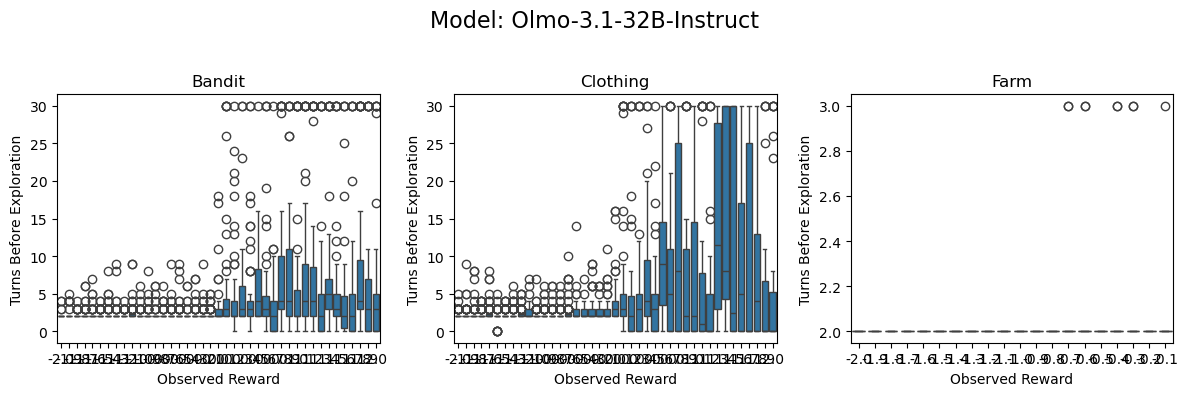

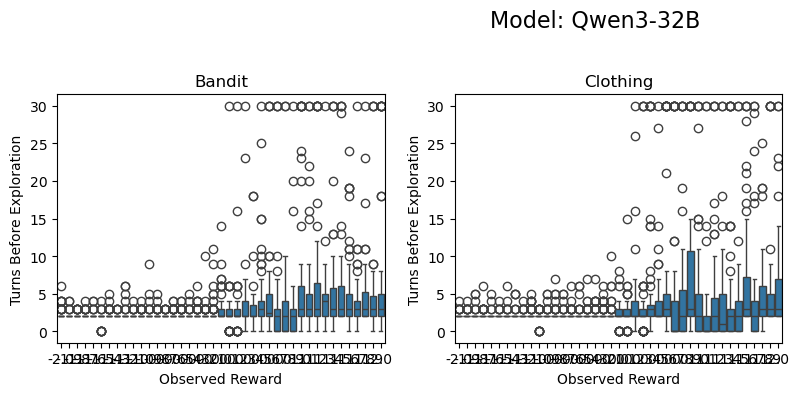

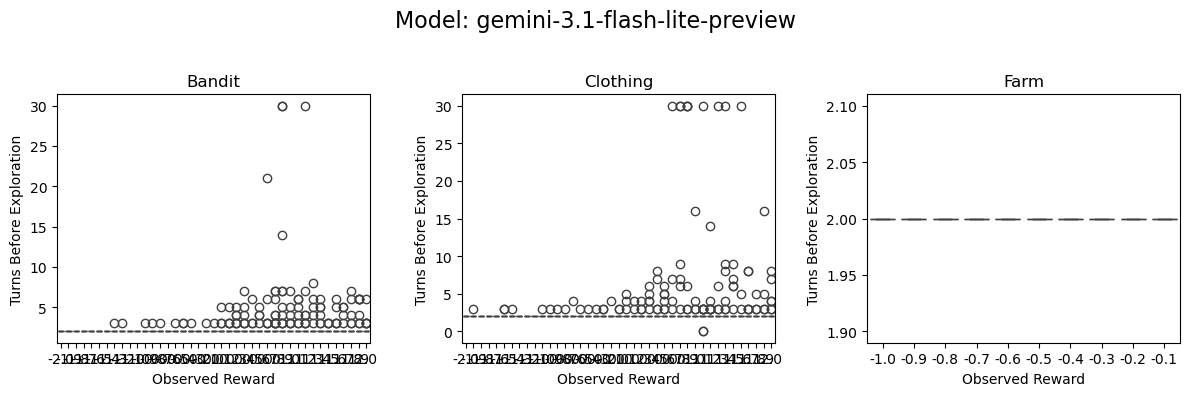

In [9]:
# Box-and-whiskers plot of `row_count` grouped by `scale`, subplot per domain and model
import math
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# Ensure expected columns exist
required_cols = {'row_count', 'scale', 'domain', 'model'}
missing = required_cols - set(replicate_df.columns)
if missing:
    raise ValueError(f"replicate_df must contain {missing} columns")

# Allow user to select scales of interest
# scales_of_interest = [0.0, 0.1, 0.8, 0.9, 1.0, 1.1, 1.2, 25.0]
# replicate_df = replicate_df[replicate_df['scale'].isin(scales_of_interest)]

# Get unique models and domains
models = sorted(replicate_df['model'].unique())
domains = sorted(replicate_df['domain'].unique())

# Create separate plots for each model
for model in models:
    model_df = replicate_df[replicate_df['model'] == model]
    if model_df.empty:
        continue

    n_domains = len(domains)
    if n_domains == 0:
        raise ValueError('No domains found in replicate_df')

    ncols = min(3, n_domains)
    nrows = math.ceil(n_domains / ncols)
    fig, axes = plt.subplots(nrows=nrows, ncols=ncols, figsize=(4 * ncols, 4 * nrows), squeeze=False)
    axes_flat = axes.flatten()

    for ax_idx, domain in enumerate(domains):
        ax = axes_flat[ax_idx]
        sub = model_df[model_df['domain'] == domain].copy()
        if sub.empty:
            ax.set_visible(False)
            continue
        # Ensure scale is numeric for correct ordering
        try:
            sub['scale'] = pd.to_numeric(sub['scale'])
        except Exception:
            pass
        sns.boxplot(x='scale', y='row_count', data=sub, ax=ax)
        ax.set_title(domain)
        ax.set_xlabel('Observed Reward')
        ax.set_ylabel('Turns Before Exploration')

    # Hide any extra empty axes
    for extra_ax in axes_flat[len(domains):]:
        extra_ax.set_visible(False)

    plt.suptitle(f"Model: {model}", fontsize=16)
    plt.tight_layout(rect=[0, 0, 1, 0.95])
    plt.show()

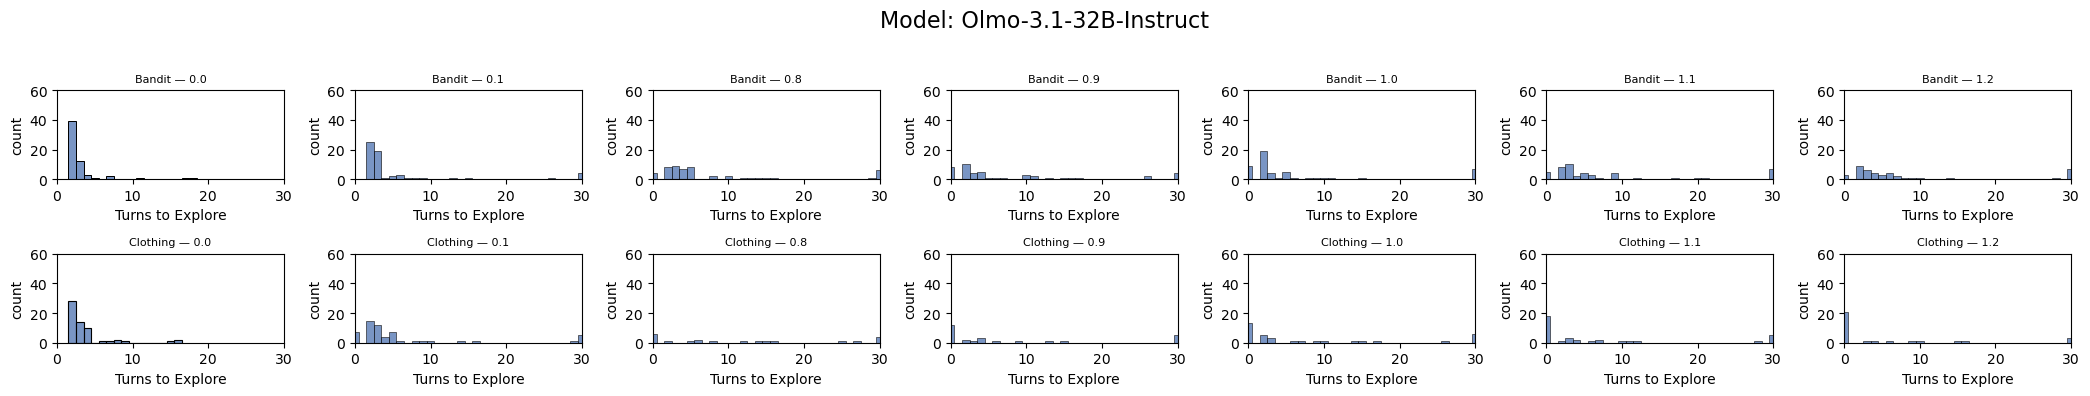

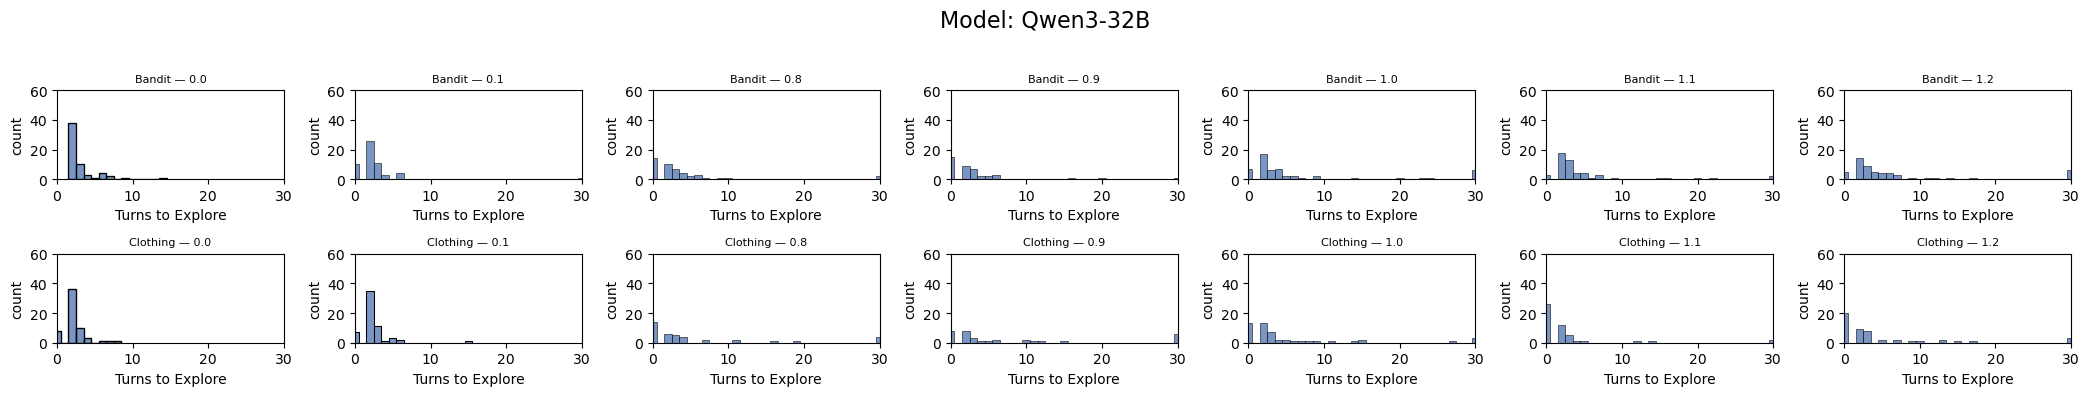

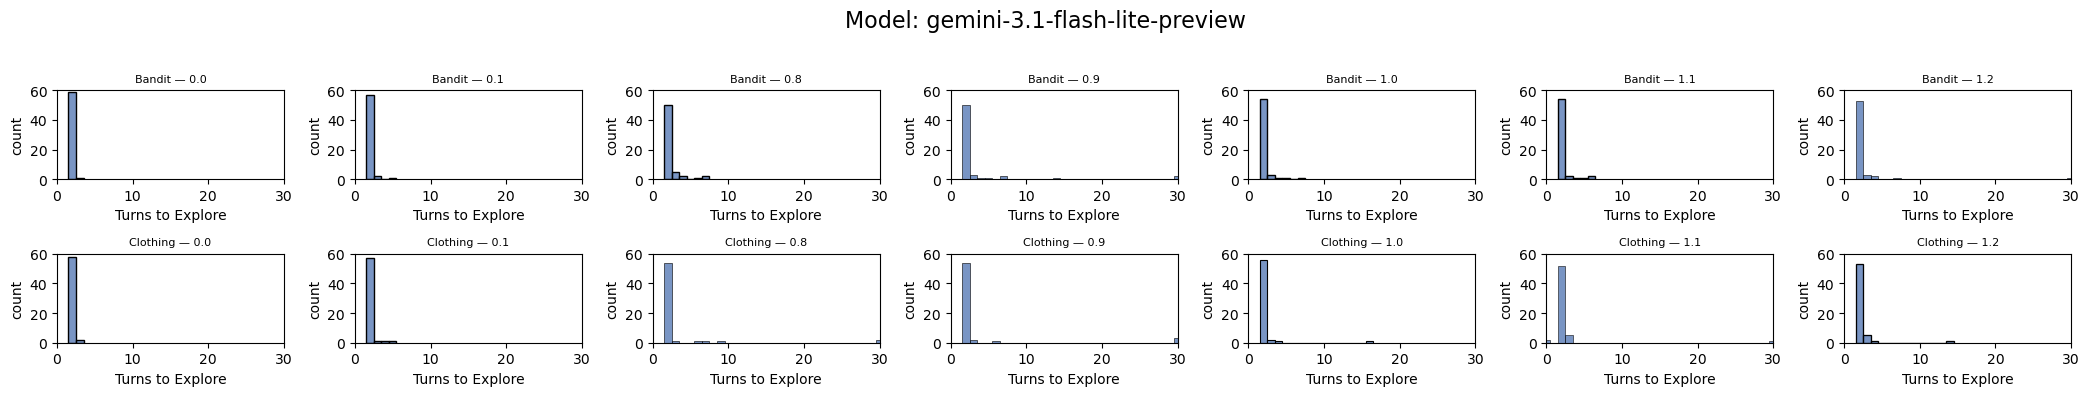

In [10]:
# Small histograms of `row_count` for each (scale, domain, model) combination
import math
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# Validate required columns
required_cols = {'scale','domain','row_count','model'}
missing = required_cols - set(replicate_df.columns)
if missing:
    raise ValueError(f"replicate_df missing required columns: {missing}")

# Allow user to select scales of interest (use a local copy to avoid mutating replicate_df)
scales_of_interest = [0.0, 0.1, 0.8, 0.9, 1.0, 1.1, 1.2, 25.0]
hist_df = replicate_df[replicate_df['scale'].isin(scales_of_interest)].copy()

# Get unique models, scales, and domains
models = sorted(hist_df['model'].unique())
domains = sorted(hist_df['domain'].unique())
scales = sorted(hist_df['scale'].unique(), key=lambda x: float(x) if pd.api.types.is_numeric_dtype(type(x)) or str(x).replace('.','',1).isdigit() else str(x))

# Determine consistent axis bounds for row_count and y-axis (count)
row_count_min = hist_df['row_count'].min()
row_count_max = hist_df['row_count'].max()
y_max = hist_df.groupby(['domain', 'scale', 'model'])['row_count'].count().max()

# Create separate plots for each model
for model in models:
    model_df = hist_df[hist_df['model'] == model]
    if model_df.empty:
        continue

    # Layout: small subplots, arrange by rows = number of domains, cols = number of scales
    nrows = len(domains)
    ncols = len(scales)
    fig, axes = plt.subplots(nrows=nrows, ncols=ncols, figsize=(3.0*ncols, 2.0*nrows), squeeze=False)
    plt.subplots_adjust(hspace=0.4, wspace=0.3)

    for i, domain in enumerate(domains):
        for j, scale in enumerate(scales):
            ax = axes[i][j]
            sub = model_df[(model_df['domain']==domain) & (model_df['scale']==scale)]
            if sub.empty:
                ax.text(0.5, 0.5, 'no data', ha='center', va='center', fontsize=8)
                ax.set_xticks([])
                ax.set_yticks([])
                ax.set_title(f"{domain}\n{scale}", fontsize=8)
                continue
            # Use discrete row_count values for histogram bins
            unique_row_counts = sorted(sub['row_count'].unique())
            sns.histplot(sub['row_count'], bins=unique_row_counts, kde=False, ax=ax, color='#4C72B0', discrete=True)
            ax.set_title(f"{domain} — {scale}", fontsize=8)
            ax.set_xlabel('Turns to Explore')
            ax.set_ylabel('count')
            ax.set_xlim(row_count_min, row_count_max)
            ax.set_ylim(0, y_max)

    plt.suptitle(f"Model: {model}", fontsize=16)
    plt.tight_layout(rect=[0, 0, 1, 0.95])
    plt.show()

## Median Turns to First Exploration by Scale
One figure: rows = models, columns = domains. X = scale, Y = median(row_count − 1). Lines = nomenclature.

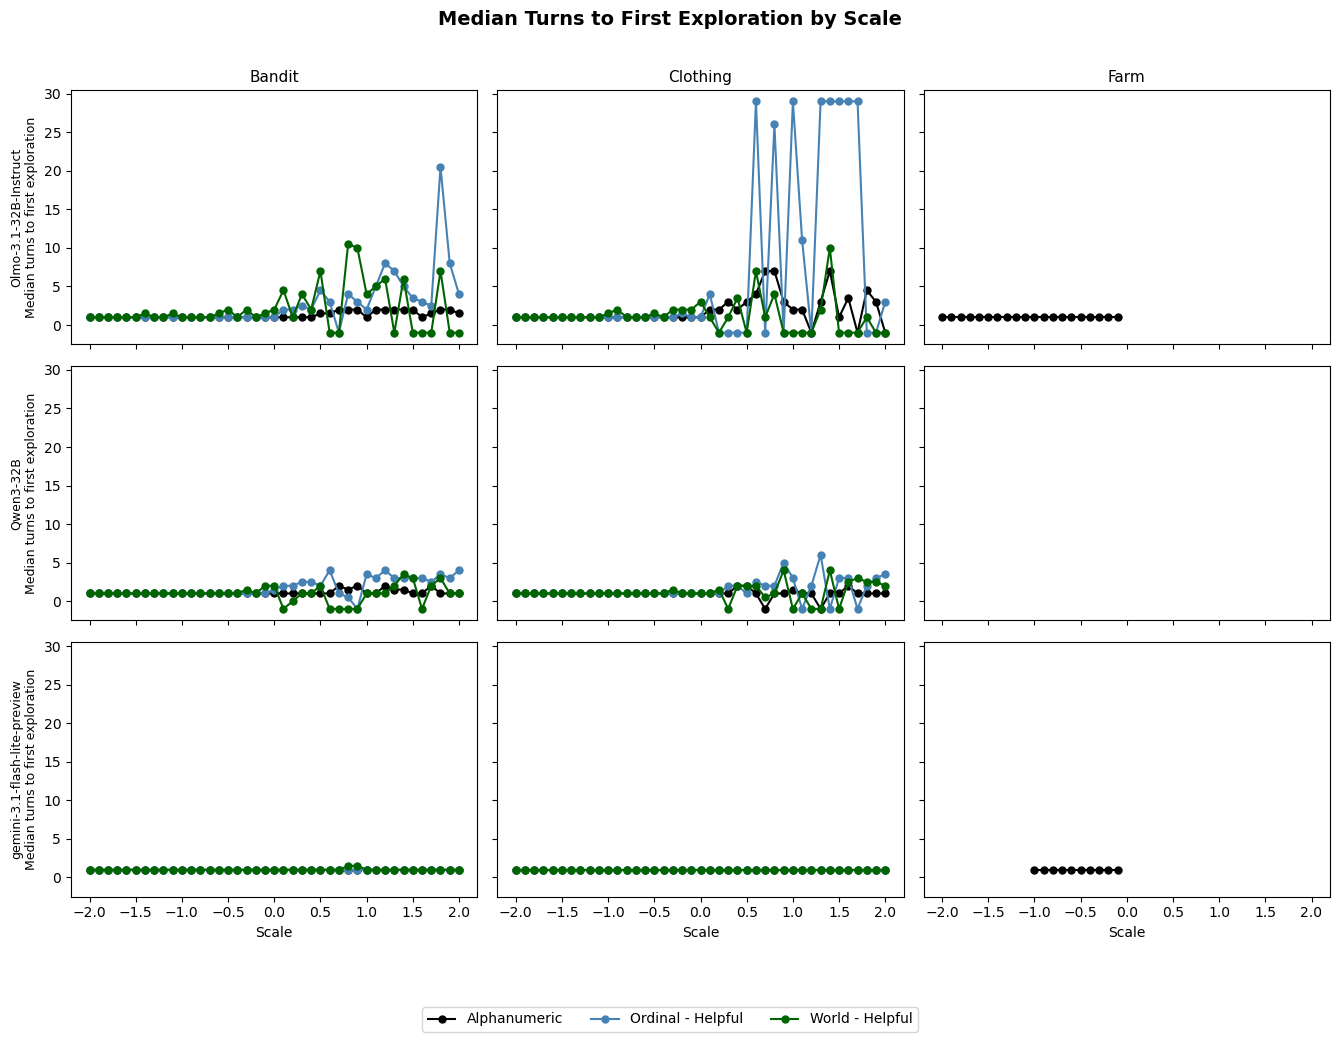

In [11]:
import math
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

# ── Style constants (matching label_channel_bias.ipynb) ──────────────────────
NOM_STYLES = {
    'alphanumeric':    {'color': 'black',         'linestyle': '-',  'marker': 'o', 'label': 'Alphanumeric'},
    'ordinal_helpful': {'color': 'steelblue',      'linestyle': '-',  'marker': 'o', 'label': 'Ordinal - Helpful'},
    'ordinal_mislead': {'color': 'cornflowerblue', 'linestyle': ':',  'marker': '^', 'label': 'Ordinal - Misleading'},
    'world_helpful':   {'color': 'darkgreen',      'linestyle': '-',  'marker': 'o', 'label': 'World - Helpful'},
    'world_mislead':   {'color': 'mediumseagreen', 'linestyle': ':',  'marker': '^', 'label': 'World - Misleading'},
}

NOMS_TO_PLOT = ['alphanumeric', 'ordinal_helpful', 'ordinal_mislead', 'world_helpful', 'world_mislead']
LEGEND_ORDER = NOMS_TO_PLOT

# ── Compute per-(model, domain, nomenclature, scale) medians ─────────────────
plot_df = (
    replicate_df[replicate_df['nomenclature'].isin(NOMS_TO_PLOT)]
    .groupby(['model', 'domain', 'nomenclature', 'scale'])
    .agg(median_first_explor=('row_count', lambda x: x.median() - 1))
    .reset_index()
)

models  = sorted(plot_df['model'].unique())
domains = sorted(plot_df['domain'].unique())

nrows = len(models)
ncols = len(domains)

fig, axes = plt.subplots(
    nrows=nrows, ncols=ncols,
    figsize=(4.5 * ncols, 3.5 * nrows),
    sharex=True, sharey=True,
    squeeze=False,
)

label_to_handle = {}

for row_idx, model in enumerate(models):
    for col_idx, domain in enumerate(domains):
        ax = axes[row_idx, col_idx]
        sub = plot_df[(plot_df['model'] == model) & (plot_df['domain'] == domain)]

        for nom in NOMS_TO_PLOT:
            nom_sub = sub[sub['nomenclature'] == nom].sort_values('scale')
            if nom_sub.empty:
                continue
            style = NOM_STYLES[nom]
            handle, = ax.plot(
                nom_sub['scale'], nom_sub['median_first_explor'],
                color=style['color'], linestyle=style['linestyle'],
                marker=style['marker'], label=style['label'],
                markersize=5, linewidth=1.5,
            )
            if style['label'] not in label_to_handle:
                label_to_handle[style['label']] = handle

        if row_idx == 0:
            ax.set_title(domain, fontsize=11)
        if col_idx == 0:
            ax.set_ylabel(f"{model}\nMedian turns to first exploration", fontsize=9)
        if row_idx == nrows - 1:
            ax.set_xlabel("Scale", fontsize=10)

# ── Shared legend at bottom ───────────────────────────────────────────────────
sorted_labels  = [NOM_STYLES[k]['label'] for k in LEGEND_ORDER if NOM_STYLES[k]['label'] in label_to_handle]
sorted_handles = [label_to_handle[lbl] for lbl in sorted_labels]

fig.legend(
    sorted_handles, sorted_labels,
    loc='lower center', bbox_to_anchor=(0.5, 0.0),
    ncol=len(sorted_handles), borderaxespad=0.5, frameon=True, fontsize=10,
)

fig.suptitle("Median Turns to First Exploration by Scale", fontsize=14, fontweight='bold')
plt.tight_layout(rect=[0, 0.08, 1, 0.97])
plt.show()

## Mean Turns to First Exploration by Scale
One figure: rows = models, columns = domains. X = scale, Y = mean(row_count − 1). Lines = nomenclature.

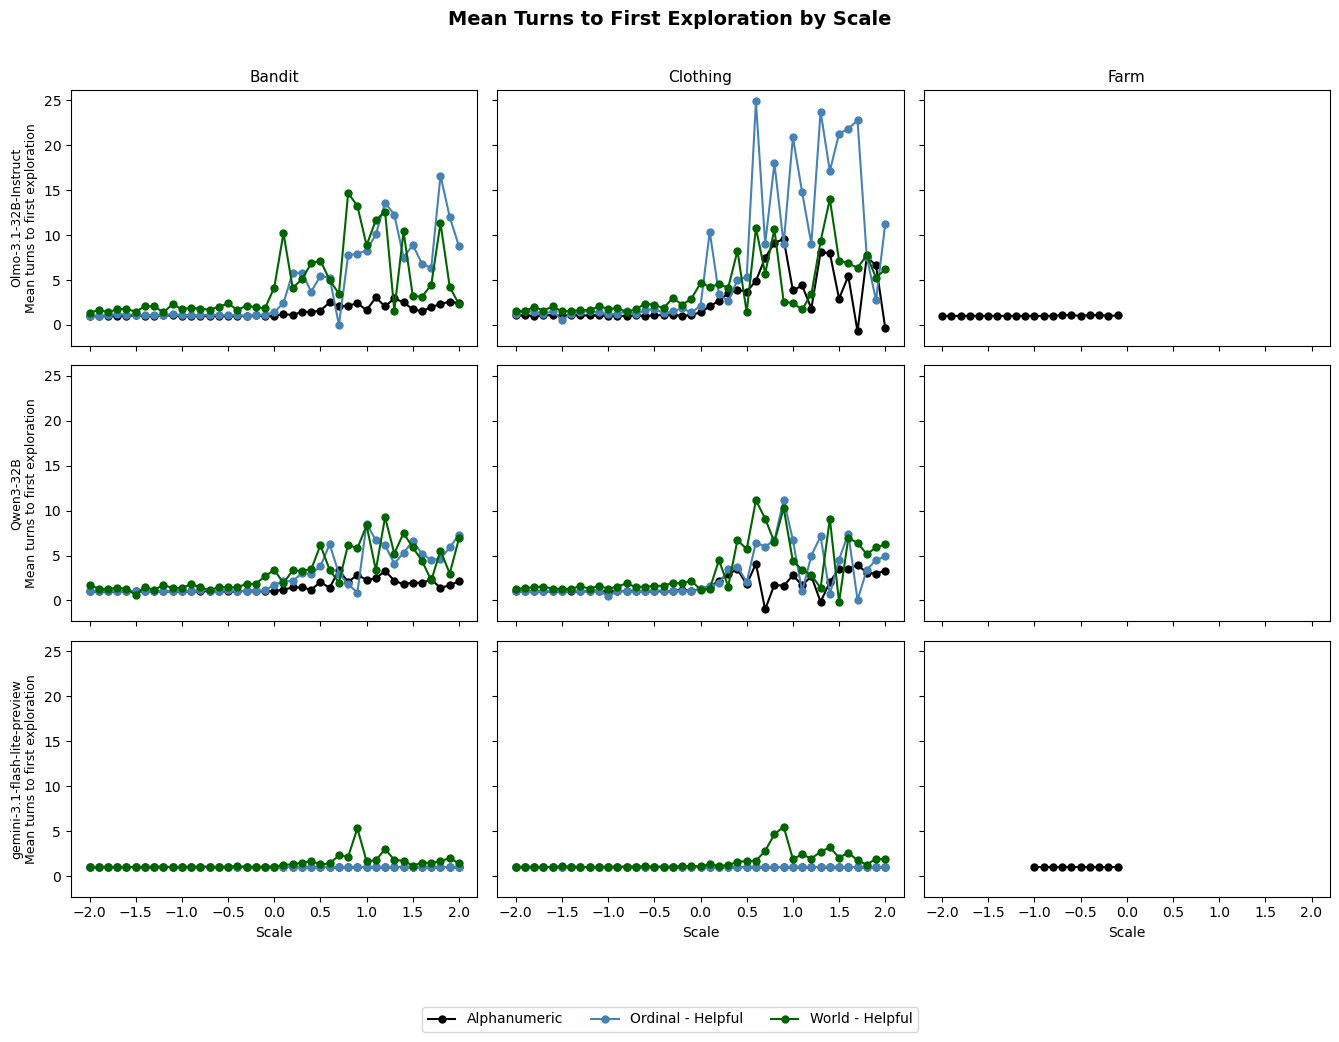

In [12]:
import math
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

# ── Style constants (matching label_channel_bias.ipynb) ──────────────────────
NOM_STYLES = {
    'alphanumeric':    {'color': 'black',         'linestyle': '-',  'marker': 'o', 'label': 'Alphanumeric'},
    'ordinal_helpful': {'color': 'steelblue',      'linestyle': '-',  'marker': 'o', 'label': 'Ordinal - Helpful'},
    'ordinal_mislead': {'color': 'cornflowerblue', 'linestyle': ':',  'marker': '^', 'label': 'Ordinal - Misleading'},
    'world_helpful':   {'color': 'darkgreen',      'linestyle': '-',  'marker': 'o', 'label': 'World - Helpful'},
    'world_mislead':   {'color': 'mediumseagreen', 'linestyle': ':',  'marker': '^', 'label': 'World - Misleading'},
}

NOMS_TO_PLOT = ['alphanumeric', 'ordinal_helpful', 'ordinal_mislead', 'world_helpful', 'world_mislead']
LEGEND_ORDER = NOMS_TO_PLOT

# ── Compute per-(model, domain, nomenclature, scale) means ───────────────────
plot_df = (
    replicate_df[replicate_df['nomenclature'].isin(NOMS_TO_PLOT)]
    .groupby(['model', 'domain', 'nomenclature', 'scale'])
    .agg(mean_first_explor=('row_count', lambda x: x.mean() - 1))
    .reset_index()
)

models  = sorted(plot_df['model'].unique())
domains = sorted(plot_df['domain'].unique())

nrows = len(models)
ncols = len(domains)

fig, axes = plt.subplots(
    nrows=nrows, ncols=ncols,
    figsize=(4.5 * ncols, 3.5 * nrows),
    sharex=True, sharey=True,
    squeeze=False,
)

label_to_handle = {}

for row_idx, model in enumerate(models):
    for col_idx, domain in enumerate(domains):
        ax = axes[row_idx, col_idx]
        sub = plot_df[(plot_df['model'] == model) & (plot_df['domain'] == domain)]

        for nom in NOMS_TO_PLOT:
            nom_sub = sub[sub['nomenclature'] == nom].sort_values('scale')
            if nom_sub.empty:
                continue
            style = NOM_STYLES[nom]
            handle, = ax.plot(
                nom_sub['scale'], nom_sub['mean_first_explor'],
                color=style['color'], linestyle=style['linestyle'],
                marker=style['marker'], label=style['label'],
                markersize=5, linewidth=1.5,
            )
            if style['label'] not in label_to_handle:
                label_to_handle[style['label']] = handle

        if row_idx == 0:
            ax.set_title(domain, fontsize=11)
        if col_idx == 0:
            ax.set_ylabel(f"{model}\nMean turns to first exploration", fontsize=9)
        if row_idx == nrows - 1:
            ax.set_xlabel("Scale", fontsize=10)

# ── Shared legend at bottom ───────────────────────────────────────────────────
sorted_labels  = [NOM_STYLES[k]['label'] for k in LEGEND_ORDER if NOM_STYLES[k]['label'] in label_to_handle]
sorted_handles = [label_to_handle[lbl] for lbl in sorted_labels]

fig.legend(
    sorted_handles, sorted_labels,
    loc='lower center', bbox_to_anchor=(0.5, 0.0),
    ncol=len(sorted_handles), borderaxespad=0.5, frameon=True, fontsize=10,
)

fig.suptitle("Mean Turns to First Exploration by Scale", fontsize=14, fontweight='bold')
plt.tight_layout(rect=[0, 0.08, 1, 0.97])
plt.show()

## Proportion of Runs Without Exploration in First 5 Turns
One figure: rows = models, columns = domains. X = scale, Y = P(row_count > 5). Lines = nomenclature.

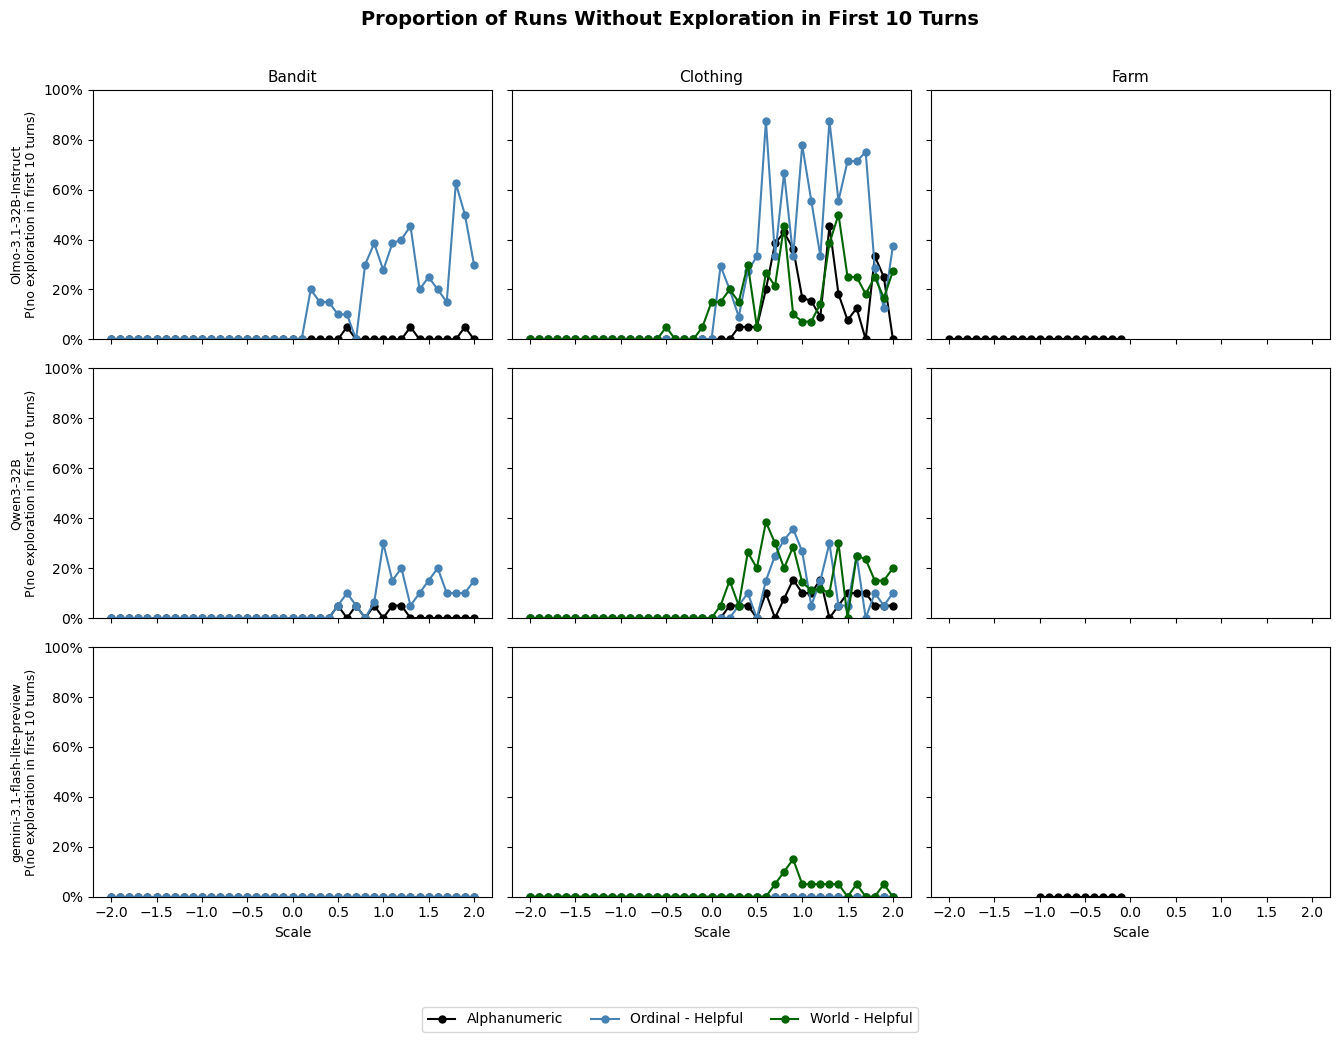

In [13]:
import math
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

EXPLORATION_THRESHOLD = 10

NOM_STYLES = {
    'alphanumeric':    {'color': 'black',         'linestyle': '-',  'marker': 'o', 'label': 'Alphanumeric'},
    'ordinal_helpful': {'color': 'steelblue',      'linestyle': '-',  'marker': 'o', 'label': 'Ordinal - Helpful'},
    'ordinal_mislead': {'color': 'cornflowerblue', 'linestyle': ':',  'marker': '^', 'label': 'Ordinal - Misleading'},
    'world_helpful':   {'color': 'darkgreen',      'linestyle': '-',  'marker': 'o', 'label': 'World - Helpful'},
    'world_mislead':   {'color': 'mediumseagreen', 'linestyle': ':',  'marker': '^', 'label': 'World - Misleading'},
}

BANDIT_NOMS = ['alphanumeric', 'ordinal_helpful']
OTHER_NOMS  = ['alphanumeric', 'ordinal_helpful', 'world_helpful']
ALL_NOMS    = list(dict.fromkeys(BANDIT_NOMS + OTHER_NOMS))
LEGEND_ORDER = ALL_NOMS

plot_df = (
    replicate_df[replicate_df['nomenclature'].isin(ALL_NOMS)]
    .groupby(['model', 'domain', 'nomenclature', 'scale'])
    .agg(prop_no_explor=('row_count', lambda x: (x > EXPLORATION_THRESHOLD).mean()))
    .reset_index()
)

models  = sorted(plot_df['model'].unique())
domains = sorted(plot_df['domain'].unique())

fig, axes = plt.subplots(
    nrows=len(models), ncols=len(domains),
    figsize=(4.5 * len(domains), 3.5 * len(models)),
    sharex=True, sharey=True,
    squeeze=False,
)

label_to_handle = {}

for row_idx, model in enumerate(models):
    for col_idx, domain in enumerate(domains):
        ax = axes[row_idx, col_idx]
        sub = plot_df[(plot_df['model'] == model) & (plot_df['domain'] == domain)]
        noms = BANDIT_NOMS if domain == 'Bandit' else OTHER_NOMS

        for nom in noms:
            nom_sub = sub[sub['nomenclature'] == nom].sort_values('scale')
            if nom_sub.empty:
                continue
            style = NOM_STYLES[nom]
            handle, = ax.plot(
                nom_sub['scale'], nom_sub['prop_no_explor'],
                color=style['color'], linestyle=style['linestyle'],
                marker=style['marker'], label=style['label'],
                markersize=5, linewidth=1.5,
            )
            if style['label'] not in label_to_handle:
                label_to_handle[style['label']] = handle

        ax.set_ylim(0, 1)
        ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda y, _: f'{y:.0%}'))
        if row_idx == 0:
            ax.set_title(domain, fontsize=11)
        if col_idx == 0:
            ax.set_ylabel(f"{model}\nP(no exploration in first {EXPLORATION_THRESHOLD} turns)", fontsize=9)
        if row_idx == len(models) - 1:
            ax.set_xlabel("Scale", fontsize=10)

sorted_labels  = [NOM_STYLES[k]['label'] for k in LEGEND_ORDER if NOM_STYLES[k]['label'] in label_to_handle]
sorted_handles = [label_to_handle[lbl] for lbl in sorted_labels]

fig.legend(
    sorted_handles, sorted_labels,
    loc='lower center', bbox_to_anchor=(0.5, 0.0),
    ncol=len(sorted_handles), borderaxespad=0.5, frameon=True, fontsize=10,
)

fig.suptitle(f"Proportion of Runs Without Exploration in First {EXPLORATION_THRESHOLD} Turns", fontsize=14, fontweight='bold')
plt.tight_layout(rect=[0, 0.08, 1, 0.97])
plt.show()

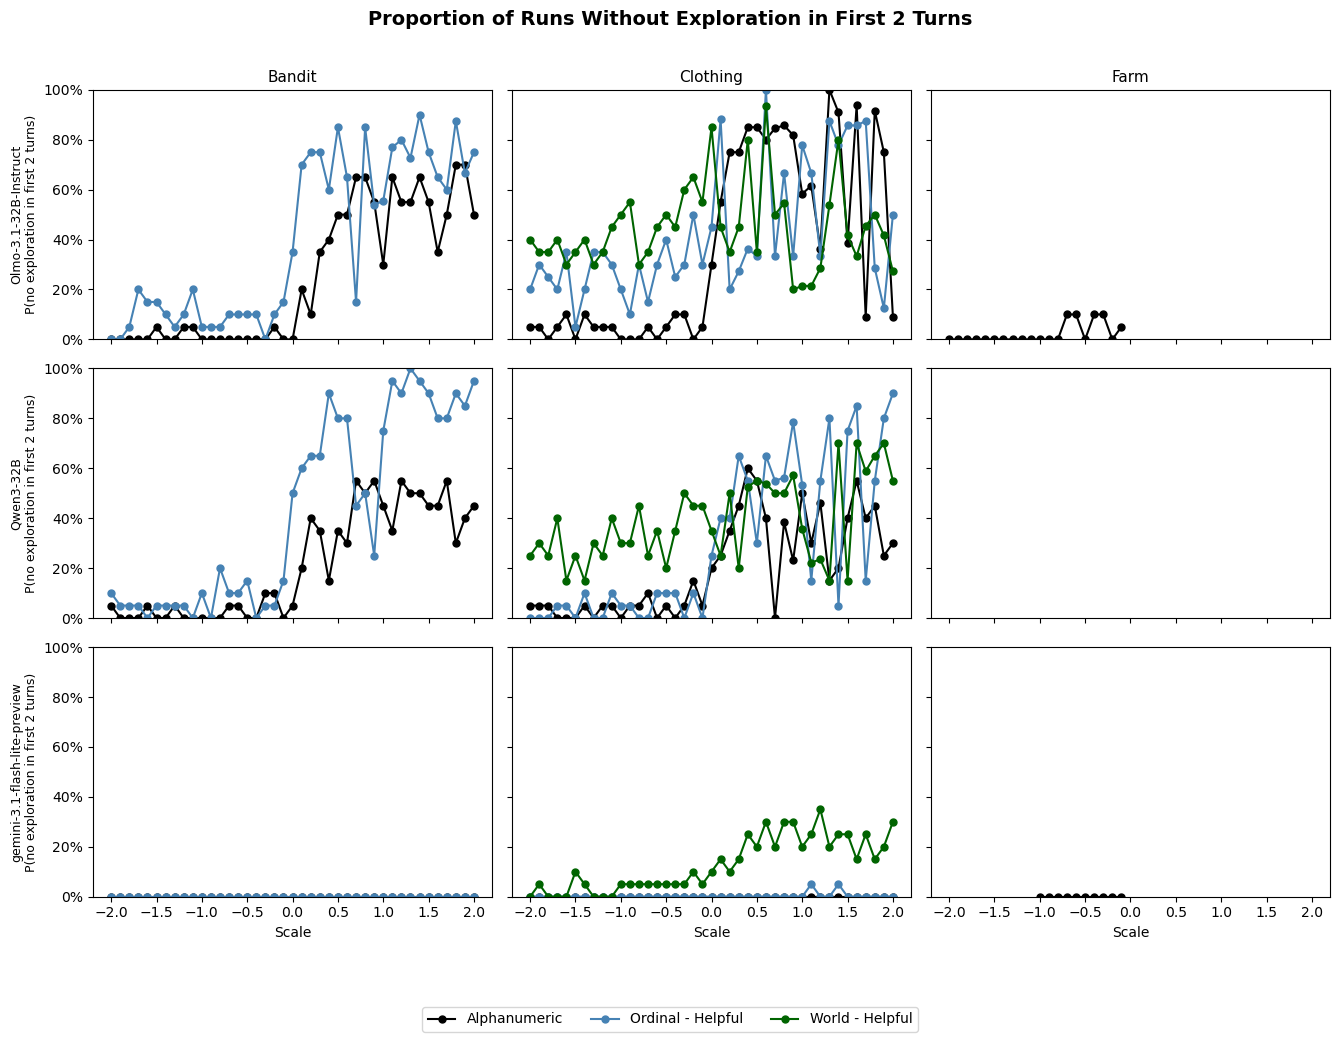

In [14]:
import math
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

EXPLORATION_THRESHOLD = 2

NOM_STYLES = {
    'alphanumeric':    {'color': 'black',         'linestyle': '-',  'marker': 'o', 'label': 'Alphanumeric'},
    'ordinal_helpful': {'color': 'steelblue',      'linestyle': '-',  'marker': 'o', 'label': 'Ordinal - Helpful'},
    'ordinal_mislead': {'color': 'cornflowerblue', 'linestyle': ':',  'marker': '^', 'label': 'Ordinal - Misleading'},
    'world_helpful':   {'color': 'darkgreen',      'linestyle': '-',  'marker': 'o', 'label': 'World - Helpful'},
    'world_mislead':   {'color': 'mediumseagreen', 'linestyle': ':',  'marker': '^', 'label': 'World - Misleading'},
}

BANDIT_NOMS = ['alphanumeric', 'ordinal_helpful']
OTHER_NOMS  = ['alphanumeric', 'ordinal_helpful', 'world_helpful']
ALL_NOMS    = list(dict.fromkeys(BANDIT_NOMS + OTHER_NOMS))
LEGEND_ORDER = ALL_NOMS

plot_df = (
    replicate_df[replicate_df['nomenclature'].isin(ALL_NOMS)]
    .groupby(['model', 'domain', 'nomenclature', 'scale'])
    .agg(prop_no_explor=('row_count', lambda x: (x > EXPLORATION_THRESHOLD).mean()))
    .reset_index()
)

models  = sorted(plot_df['model'].unique())
domains = sorted(plot_df['domain'].unique())

fig, axes = plt.subplots(
    nrows=len(models), ncols=len(domains),
    figsize=(4.5 * len(domains), 3.5 * len(models)),
    sharex=True, sharey=True,
    squeeze=False,
)

label_to_handle = {}

for row_idx, model in enumerate(models):
    for col_idx, domain in enumerate(domains):
        ax = axes[row_idx, col_idx]
        sub = plot_df[(plot_df['model'] == model) & (plot_df['domain'] == domain)]
        noms = BANDIT_NOMS if domain == 'Bandit' else OTHER_NOMS

        for nom in noms:
            nom_sub = sub[sub['nomenclature'] == nom].sort_values('scale')
            if nom_sub.empty:
                continue
            style = NOM_STYLES[nom]
            handle, = ax.plot(
                nom_sub['scale'], nom_sub['prop_no_explor'],
                color=style['color'], linestyle=style['linestyle'],
                marker=style['marker'], label=style['label'],
                markersize=5, linewidth=1.5,
            )
            if style['label'] not in label_to_handle:
                label_to_handle[style['label']] = handle

        ax.set_ylim(0, 1)
        ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda y, _: f'{y:.0%}'))
        if row_idx == 0:
            ax.set_title(domain, fontsize=11)
        if col_idx == 0:
            ax.set_ylabel(f"{model}\nP(no exploration in first {EXPLORATION_THRESHOLD} turns)", fontsize=9)
        if row_idx == len(models) - 1:
            ax.set_xlabel("Scale", fontsize=10)

sorted_labels  = [NOM_STYLES[k]['label'] for k in LEGEND_ORDER if NOM_STYLES[k]['label'] in label_to_handle]
sorted_handles = [label_to_handle[lbl] for lbl in sorted_labels]

fig.legend(
    sorted_handles, sorted_labels,
    loc='lower center', bbox_to_anchor=(0.5, 0.0),
    ncol=len(sorted_handles), borderaxespad=0.5, frameon=True, fontsize=10,
)

fig.suptitle(f"Proportion of Runs Without Exploration in First {EXPLORATION_THRESHOLD} Turns", fontsize=14, fontweight='bold')
plt.tight_layout(rect=[0, 0.08, 1, 0.97])
plt.show()